<a href="https://colab.research.google.com/github/PzykoEich/proyecto_NLP/blob/main/proyecto_copia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# En este momento no se que debo hacer 😅

# Verificación de emociones

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import nltk
import spacy
import kagglehub
import random
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
import re

In [3]:
#Load data from kaggle
path = kagglehub.dataset_download("sbhatti/financial-sentiment-analysis", path='data.csv')

100%|██████████| 728k/728k [00:00<00:00, 12.6MB/s]


In [12]:
df = pd.read_csv(path)
df.columns = ['comentario', 'sentimiento']

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5842 entries, 0 to 5841
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   comentario   5842 non-null   object
 1   sentimiento  5842 non-null   object
dtypes: object(2)
memory usage: 91.4+ KB


In [14]:
df

,comentario,sentimiento
0,The GeoSolutions technology will leverage Bene...,positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,According to the Finnish-Russian Chamber of Co...,neutral
4,The Swedish buyout firm has sold its remaining...,neutral
...,...,...
5837,RISING costs have forced packaging producer Hu...,negative
5838,Nordic Walking was first used as a summer trai...,neutral
5839,"According shipping company Viking Line , the E...",neutral
5840,"In the building and home improvement trade , s...",neutral


In [15]:
df['sentimiento'].value_counts()

,count
sentimiento,
neutral,3130
positive,1852
negative,860


In [20]:
df.convert_dtypes()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5842 entries, 0 to 5841
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   comentario   5842 non-null   string
 1   sentimiento  5842 non-null   object
dtypes: object(1), string(1)
memory usage: 91.4+ KB


In [21]:
#Estableciendo semillas

seed = 40
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

In [22]:
nltk.download('punkt')  #tokenizer de nltk
nltk.download('punkt_tab')  #tokenizer de nltk
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [23]:
stopwords_en = stopwords.words('english')

In [26]:
#Limpieza de texto
def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r"http\S+", "", texto)
    texto = re.sub(r"@\w+", "", texto)
    texto = re.sub(r"#\w+", "", texto)
    #texto = re.sub(r"[^a-záéíóúñ ]", "", texto)
    palabras = texto.split()
    palabras = [p for p in palabras if p not in stopwords_en]
    return " ".join(palabras)

In [27]:
df['comentario_limpio'] = df['comentario'].apply(limpiar_texto)
df

,comentario,sentimiento,comentario_limpio
0,The GeoSolutions technology will leverage Bene...,positive,geosolutions technology leverage benefon 's gp...
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative,"$esi lows, $1.50 $2.50 bk real possibility"
2,"For the last quarter of 2010 , Componenta 's n...",positive,"last quarter 2010 , componenta 's net sales do..."
3,According to the Finnish-Russian Chamber of Co...,neutral,"according finnish-russian chamber commerce , m..."
4,The Swedish buyout firm has sold its remaining...,neutral,swedish buyout firm sold remaining 22.4 percen...
...,...,...,...
5837,RISING costs have forced packaging producer Hu...,negative,rising costs forced packaging producer huhtama...
5838,Nordic Walking was first used as a summer trai...,neutral,nordic walking first used summer training meth...
5839,"According shipping company Viking Line , the E...",neutral,"according shipping company viking line , eu de..."
5840,"In the building and home improvement trade , s...",neutral,"building home improvement trade , sales decrea..."


In [31]:
vetorizer = TfidfVectorizer()
tfidf_matrix = vetorizer.fit_transform(df['comentario_limpio'])
words = vetorizer.get_feature_names_out()
corpus_scores = tfidf_matrix.sum(axis=0).A1

In [34]:
tfidf_scores = dict(zip(words, corpus_scores))

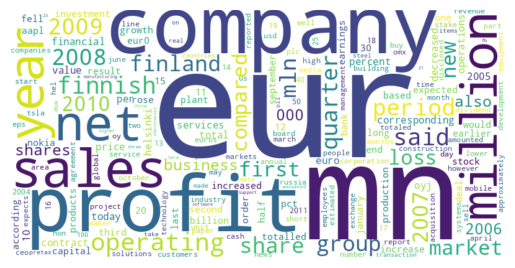

In [35]:
wordcloud = WordCloud(background_color='white', width=800, height=400).generate_from_frequencies(tfidf_scores)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

# Análisis de sentimientos

In [36]:

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


In [37]:
encoder = LabelEncoder()
df['sentimiento_encoded'] = encoder.fit_transform(df['sentimiento'])

In [38]:
df

,comentario,sentimiento,comentario_limpio,sentimiento_encoded
0,The GeoSolutions technology will leverage Bene...,positive,geosolutions technology leverage benefon 's gp...,2
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative,"$esi lows, $1.50 $2.50 bk real possibility",0
2,"For the last quarter of 2010 , Componenta 's n...",positive,"last quarter 2010 , componenta 's net sales do...",2
3,According to the Finnish-Russian Chamber of Co...,neutral,"according finnish-russian chamber commerce , m...",1
4,The Swedish buyout firm has sold its remaining...,neutral,swedish buyout firm sold remaining 22.4 percen...,1
...,...,...,...,...
5837,RISING costs have forced packaging producer Hu...,negative,rising costs forced packaging producer huhtama...,0
5838,Nordic Walking was first used as a summer trai...,neutral,nordic walking first used summer training meth...,1
5839,"According shipping company Viking Line , the E...",neutral,"according shipping company viking line , eu de...",1
5840,"In the building and home improvement trade , s...",neutral,"building home improvement trade , sales decrea...",1


In [40]:
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(df['comentario_limpio'])

sequences = tokenizer.texts_to_sequences(df['comentario_limpio'])
padded = pad_sequences(sequences, maxlen=100, padding="post")

In [41]:
X_train, X_test, y_train, y_test = train_test_split(padded, df['sentimiento_encoded'], test_size=0.2, random_state=42)

In [42]:

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(10000, 64, input_length=100),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(3, activation="softmax")  # 3 classes
])

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [43]:

history = model.fit(
    X_train,
    y_train,
    epochs=10,      # 🔥 You can change this number
    batch_size=32,
    validation_split=0.2
)


Epoch 1/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.5455 - loss: 0.9810 - val_accuracy: 0.5016 - val_loss: 1.0112
Epoch 2/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5455 - loss: 0.9718 - val_accuracy: 0.5016 - val_loss: 1.0057
Epoch 3/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5452 - loss: 0.9638 - val_accuracy: 0.5016 - val_loss: 0.9965
Epoch 4/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5492 - loss: 0.9430 - val_accuracy: 0.4963 - val_loss: 0.9763
Epoch 5/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5800 - loss: 0.9003 - val_accuracy: 0.5968 - val_loss: 0.9520
Epoch 6/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6330 - loss: 0.8356 - val_accuracy: 0.5604 - val_loss: 0.9146
Epoch 7/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6779 - loss: 0.7603 - val_accuracy: 0.5850 - val_loss: 0.9015
Epoch 8/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7183 - loss: 0.6944 - val_accuracy: 

In [44]:
model.evaluate(X_test, y_test)

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6544 - loss: 0.8525


[0.8525037169456482, 0.6544054746627808]

In [53]:

new_comment = "I loose everything in the last Quater"
def prueba(new_comment):
  lista = []
  texto = limpiar_texto(new_comment)
  lista.append(texto)
  seq = tokenizer.texts_to_sequences(lista)
  pad = pad_sequences(seq, maxlen=100)

  pred = model.predict(pad)
  sentiment = encoder.inverse_transform([pred.argmax()])

  print(sentiment)

prueba(new_comment)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
['neutral']


In [56]:

model_2 = tf.keras.Sequential([
    tf.keras.layers.Embedding(20000, 128, input_length=100),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(3, activation="softmax")
])


model_2.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

history = model.fit(
    X_train,
    y_train,
    epochs=15,      # 🔥 You can change this number
    batch_size=32,
    validation_split=0.2
)

Epoch 1/15
  1/117 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.9375 - loss: 0.3748

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7919 - loss: 0.5244 - val_accuracy: 0.6086 - val_loss: 0.9588
Epoch 2/15
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8087 - loss: 0.4838 - val_accuracy: 0.6096 - val_loss: 0.9779
Epoch 3/15
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8202 - loss: 0.4493 - val_accuracy: 0.6064 - val_loss: 0.9787
Epoch 4/15
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8291 - loss: 0.4213 - val_accuracy: 0.6128 - val_loss: 0.9761
Epoch 5/15
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8331 - loss: 0.4063 - val_accuracy: 0.6182 - val_loss: 1.0273
Epoch 6/15
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8208 - loss: 0.4292 - val_accuracy: 0.6160 - val_loss: 1.0374
Epoch 7/15
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7903 - loss: 0.4896 - val_accuracy: 0.6492 - val_loss: 0.8828
Epoch 8/15
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8258 - loss: 0.4120 - val_accuracy: 0.6406 - val_

In [57]:
model_2.evaluate(X_test, y_test)

37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 140ms/step - accuracy: 0.2583 - loss: 1.1031


[1.1030761003494263, 0.258340448141098]

In [59]:

new_comment = "I hate the live"
def prueba(new_comment):
  lista = []
  texto = limpiar_texto(new_comment)
  lista.append(texto)
  seq = tokenizer.texts_to_sequences(lista)
  pad = pad_sequences(seq, maxlen=100)

  pred = model_2.predict(pad)
  sentiment = encoder.inverse_transform([pred.argmax()])

  print(sentiment)

prueba(new_comment)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
['positive']
